In [1]:
"""
Study Hours vs Final Scores
"""

import pandas as pd

data = pd.DataFrame({
    'hours_studied': [2, 4, 6, 8, 10],   
    'final_scores': [50, 60, 70, 80, 90]
})
data

,hours_studied,final_scores
0,2,50
1,4,60
2,6,70
3,8,80
4,10,90


#### Suppose from the dataset above, our linear equation becomes:
#### y = mx + c
#### y = 5x + 40
#### This means, when the study hours increases by 1 hour, the final score increase by 5 marks. The intercept, 40 is the predicted score when the study hours is 0.

#### Factoring in the residual, the simple linear regression equation becomes:
#### y = mx + c + e
#### e means the error term
#### If you have a residual of 3, it means the model predicts 3 marks lower than the actual value. If it's 5, it means the model predicts 5 marks higher than the actual value.
#### The residuals help to tell us how wrong the model is.
#### There are various error metrics
#### R-Squared
#### MAE (Mean Absolute Error)
#### MSE (Mean Squared Error)
#### RMSE(Root Mean Squared Error)

In [6]:
import statsmodels.api as sm

data = pd.DataFrame({
    'hours_studied': [1, 1, 2, 3, 4, 6, 8, 10, 12, 14],
    'final_scores': [30, 40, 50, 57, 60, 70, 80, 87, 90, 100]
})

data

,hours_studied,final_scores
0,1,30
1,1,40
2,2,50
3,3,57
4,4,60
5,6,70
6,8,80
7,10,87
8,12,90
9,14,100


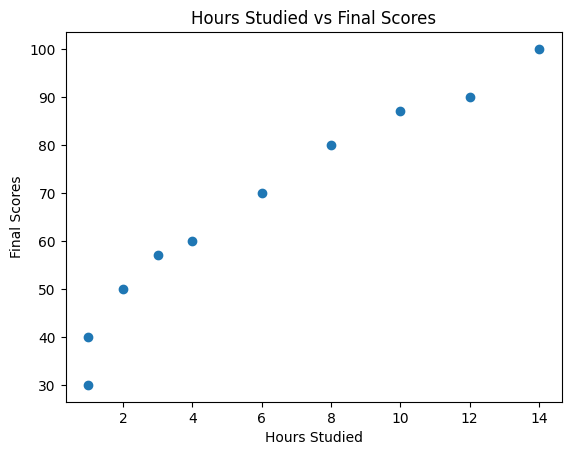

In [7]:
import matplotlib.pyplot as plt
X = data['hours_studied']
y = data['final_scores']

plt.scatter(X, y)
plt.xlabel('Hours Studied')
plt.ylabel('Final Scores')
plt.title('Hours Studied vs Final Scores')
plt.show()

In [8]:
# fit the linear regression model

# Estimate the intercept by adding a column to X
X = sm.add_constant(X)

# Fit the regression model/ OLS stands for Ordinary Least Squares
model = sm.OLS(y, X).fit()

# Print the model summary
model.summary()

c:\Users\25473\anaconda3\envs\win_c0c1\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           final_scores   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                     127.0
Date:                Thu, 28 May 2026   Prob (F-statistic):           3.46e-06
Time:                        11:11:07   Log-Likelihood:                -30.856
No. Observations:                  10   AIC:                             65.71
Df Residuals:                       8   BIC:                             66.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            37.5530      3.171     11.841      0.000      30.240      44.866
hours_studied     4.7290      0.420     11.267      0.000       3.761       5.697
==============================================================================
Omnibus:                        4.591   Durbin-Watson:                   0.658
Prob(Omnibus):                  0.101   Jarque-Bera (JB):                1.965
Skew:                          -1.082   Prob(JB):                        0.374
Kurtosis:                       3.192   Cond. No.                         13.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import numpy as np

y_pred = model.predict(X)

# Calculate evaluation metrics - It's comparison between actual and predicted values
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Root Mean Squared Error: {rmse}')


Mean Absolute Error: 4.524886877828057
Mean Squared Error: 28.029361488185003
R-squared: 0.9407212556294201
Root Mean Squared Error: 5.294276295036462


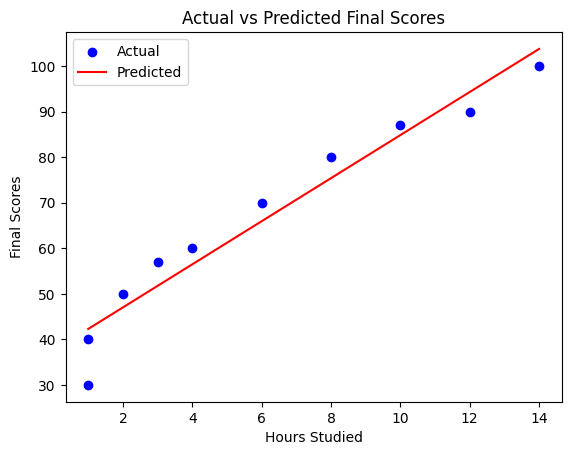

In [13]:
# Draw the regression line
plt.scatter(X['hours_studied'], y, label='Actual', color='blue')
plt.plot(X['hours_studied'], y_pred, label='Predicted', color='red') # Re
plt.xlabel('Hours Studied')
plt.ylabel('Final Scores')
plt.title('Actual vs Predicted Final Scores')
plt.legend()
plt.show()

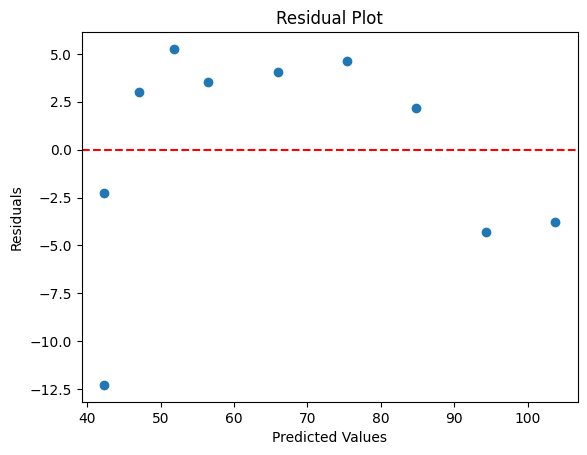

In [10]:
"""
Residual Plot
"""
residuals = y - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
# plot the Actual Final Score vs Predicted Final Score (Shade using different colors)
